In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("traffic.csv")
df['DateTime'] = pd.to_datetime(df['DateTime'])

df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [3]:
df['hour'] = df['DateTime'].dt.hour
df['day'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month
df['day_of_week'] = df['DateTime'].dt.dayofweek

df.head()

,DateTime,Junction,Vehicles,ID,hour,day,month,day_of_week
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,6
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,6
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,6


In [4]:
df['hour'] = df['DateTime'].dt.hour
df['day'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month
df['day_of_week'] = df['DateTime'].dt.dayofweek

df.head()

,DateTime,Junction,Vehicles,ID,hour,day,month,day_of_week
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,6
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,6
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,6


In [5]:
def traffic_level(v):
    if v < 20:
        return 0   # Low
    elif v < 40:
        return 1   # Medium
    else:
        return 2   # High

df['Traffic_Level'] = df['Vehicles'].apply(traffic_level)

df[['Vehicles','Traffic_Level']].head()

,Vehicles,Traffic_Level
0,15,0
1,13,0
2,10,0
3,7,0
4,9,0


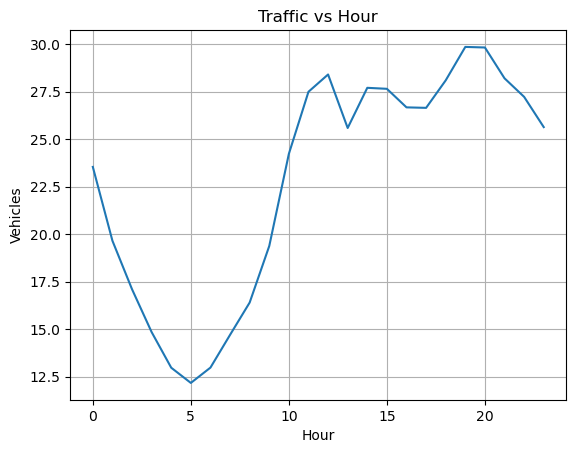

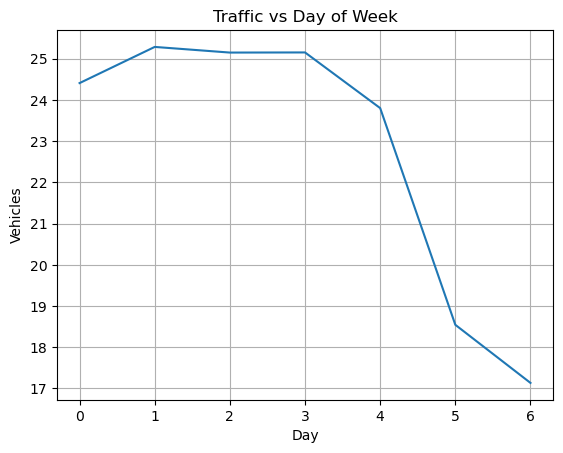

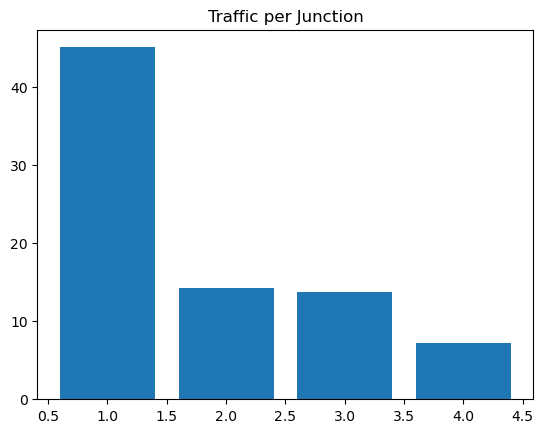

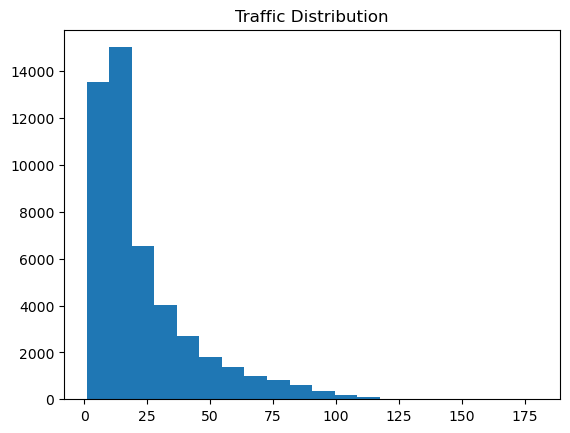

In [6]:
# Traffic vs Hour
hourly = df.groupby('hour')['Vehicles'].mean()
plt.figure()
plt.plot(hourly.index, hourly.values)
plt.title("Traffic vs Hour")
plt.xlabel("Hour")
plt.ylabel("Vehicles")
plt.grid()
plt.show()

# Traffic vs Day
dow = df.groupby('day_of_week')['Vehicles'].mean()
plt.figure()
plt.plot(dow.index, dow.values)
plt.title("Traffic vs Day of Week")
plt.xlabel("Day")
plt.ylabel("Vehicles")
plt.grid()
plt.show()

# Junction Traffic
junction = df.groupby('Junction')['Vehicles'].mean()
plt.figure()
plt.bar(junction.index, junction.values)
plt.title("Traffic per Junction")
plt.show()

# Distribution
plt.figure()
plt.hist(df['Vehicles'], bins=20)
plt.title("Traffic Distribution")
plt.show()

In [7]:
X = df[['hour', 'day', 'month', 'day_of_week', 'Junction']]
y = df['Traffic_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8273067331670823

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92      5974
           1       0.65      0.59      0.62      2102
           2       0.74      0.76      0.75      1548

    accuracy                           0.83      9624
   macro avg       0.76      0.76      0.76      9624
weighted avg       0.82      0.83      0.82      9624



Confusion Matrix:
 [[5550  349   75]
 [ 516 1241  345]
 [  71  306 1171]]


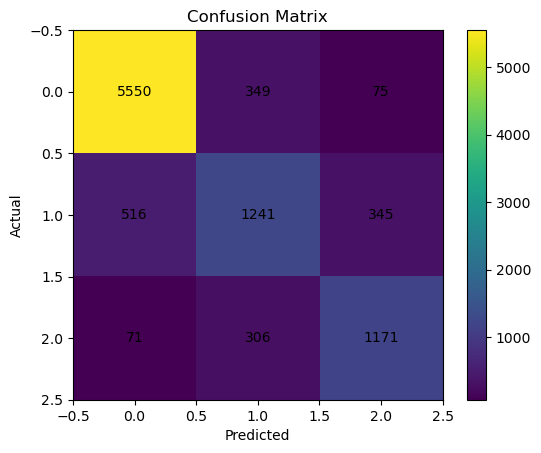

In [9]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.colorbar()
plt.show()

In [10]:
G = nx.Graph()

junctions = df['Junction'].unique()

# Add nodes
for j in junctions:
    G.add_node(j)

# Create connections
for i in range(len(junctions)-1):
    G.add_edge(junctions[i], junctions[i+1])

if len(junctions) > 2:
    G.add_edge(junctions[0], junctions[-1])

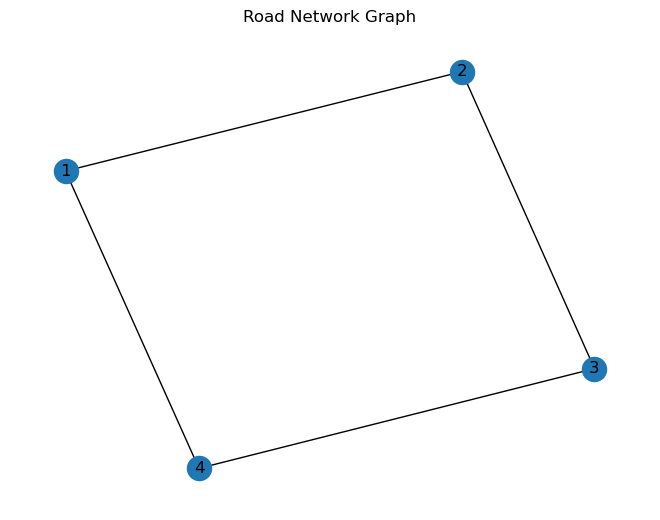

In [11]:
plt.figure()
nx.draw(G, with_labels=True)
plt.title("Road Network Graph")
plt.show()

In [12]:
# Example inputs (change anytime)
source = junctions[0]
destination = junctions[-1]

hour = 18
day = 10
month = 5
dow = 2

# Assign weights
for u, v in G.edges():
    pred = model.predict([[hour, day, month, dow, u]])[0]

    if pred == 0:
        weight = 10
    elif pred == 1:
        weight = 20
    else:
        weight = 30

    G[u][v]['weight'] = weight

# Find route
path = nx.dijkstra_path(G, source=source, target=destination, weight='weight')
cost = nx.dijkstra_path_length(G, source=source, target=destination, weight='weight')

print("Best Route:", path)
print("Total Cost:", cost)

if cost < 30:
    print("Traffic: LOW")
elif cost < 60:
    print("Traffic: MEDIUM")
else:
    print("Traffic: HIGH")

Best Route: [1, 4]
Total Cost: 30
Traffic: MEDIUM


c:\Users\reddy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\reddy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\reddy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\reddy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
